# 04.5 - Origin Classification with ModernBERT + Extra Review Text (SCRUBBED+)

This notebook adds a **third scrub tier** on top of 04.4: cultivar names and Spanish-language
producer-context terms that correlate strongly with origin but are not country names.

The point is to decompose the signal finer. The 04.4 post-hoc audit revealed that even with all
country and region names scrubbed, F1 was still 0.669 because the model was picking up:

- **Cultivar names**: `SL28`/`SL34` -> Kenya (~85%), `Gesha`/`Geisha` -> Panama (~45%),
  `Pacamara` -> El Salvador (~44%), `Heirloom` -> Ethiopia/Burundi/El Salvador,
  `Bourbon`/`Caturra`/`Catuai`/`Typica` -> Latin America, `Castillo` -> Colombia.
- **Producer-context terms**: `finca`/`hacienda`/`beneficio` are Spanish words that by themselves
  signal Latin America. `washing station` is an East African convention. `cup of excellence` is a
  Latin American competition.

## What this notebook measures

04.5 gives us a **fourth point** on the decomposition curve, quantifying how much of the 04.4 signal
came from cultivar knowledge vs actual flavor description.

## Expected ordering

| Notebook | Macro-F1 | What the model sees |
|---|---|---|
| 04.2 | 0.182 | Blind Assessment only |
| 04.3 | 0.888 | Full concat, no scrub (leakage ceiling) |
| 04.4 | 0.669 | Full concat, country + region scrubbed |
| **04.5** | **expected 0.25-0.45** | Full concat, + cultivars + producer context scrubbed |

If 04.5 lands near 0.20, the extra text was almost all cultivar/Spanish signal. If it lands near
0.45-0.60, there is still legitimate contextual signal (processing notes, elevation, adjectives)
that the model can use beyond the classical blind-cup flavor vocabulary.

## Config: same ModernBERT recipe as 04.2/04.3/04.4 for fair comparison.


In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding,
    EarlyStoppingCallback, Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback


In [2]:
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'answerdotai/ModernBERT-base'
TEXT_COLUMN = 'text_full_concat_scrubbed_plus'
MAX_LENGTH = 256

# Best config from 04.2 seed harness
BEST_LR = 3e-5
USE_CLASS_WEIGHTS = False

NUM_TRAIN_EPOCHS = 12
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
EARLY_STOP_PATIENCE = 3
USE_FP16 = True

OUTPUT_DIR_ROOT = 'artifacts/origin_finetuning_modernbert_fulltext_scrubbed_plus'
os.makedirs(OUTPUT_DIR_ROOT, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)


Device: cuda


## Build the combined scrubbing vocabulary (countries + regions + cultivars + producer context)

In [3]:
# Tier 1 + Tier 2 (same as 04.4): country names, adjectival forms, coffee-region aliases
COUNTRY_TERMS = {
    "Ethiopia": ["ethiopia", "ethiopian"],
    "Colombia": ["colombia", "colombian", "columbian"],
    "Panama": ["panama", "panamanian"],
    "Kenya": ["kenya", "kenyan"],
    "Indonesia": ["indonesia", "indonesian"],
    "Guatemala": ["guatemala", "guatemalan"],
    "Costa Rica": ["costa rica", "costa rican", "costarican"],
    "El Salvador": ["el salvador", "salvadoran", "salvadorean", "salvadorian"],
    "Rwanda": ["rwanda", "rwandan"],
    "Brazil": ["brazil", "brazilian"],
    "Honduras": ["honduras", "honduran"],
    "Peru": ["peru", "peruvian"],
    "Taiwan": ["taiwan", "taiwanese"],
    "Papua New Guinea": ["papua new guinea", "papua new guinean"],
    "Nicaragua": ["nicaragua", "nicaraguan"],
    "Burundi": ["burundi", "burundian"],
    "Thailand": ["thailand", "thai"],
    "India": ["india", "indian"],
    "Mexico": ["mexico", "mexican"],
    "Tanzania": ["tanzania", "tanzanian"],
    "Yemen": ["yemen", "yemeni"],
    "Ecuador": ["ecuador", "ecuadorian"],
    "Bolivia": ["bolivia", "bolivian"],
    "Jamaica": ["jamaica", "jamaican"],
    "Uganda": ["uganda", "ugandan"],
    "Dominican Republic": ["dominican republic", "dominican"],
    "Zambia": ["zambia", "zambian"],
    "China": ["china", "chinese"],
    "Vietnam": ["vietnam", "vietnamese"],
    "Philippines": ["philippines", "philippine", "filipino"],
    "Malaysia": ["malaysia", "malaysian"],
    "Laos": ["laos", "laotian"],
    "Zimbabwe": ["zimbabwe", "zimbabwean"],
    "Haiti": ["haiti", "haitian"],
    "Puerto Rico": ["puerto rico", "puerto rican", "puertorican"],
    "Nepal": ["nepal", "nepalese", "nepali"],
    "Myanmar": ["myanmar", "burmese"],
    "Cameroon": ["cameroon", "cameroonian"],
    "Australia": ["australia", "australian"],
    "South Africa": ["south africa", "south african"],
    "Malawi": ["malawi", "malawian"],
    "Venezuela": ["venezuela", "venezuelan", "merida state", "mocoties valley"],
    "Timor-Leste": ["east timor", "timor leste", "timorese"],
    "DR Congo": ["democratic republic of the congo", "dr congo", "congo", "congolese"],
    "United Kingdom": ["united kingdom", "british", "pitcairn island", "saint helena", "st helena", "sandy bay valley"],
    "United States": [
        "usa", "united states", "american",
        "hawaii", "hawai'i", "hawaiian", "hawaii island",
        "big island", "kona", "puna district", "holualoa", "oahu", "maui", "kauai",
        "ka u", "ka'u", "kau",
    ],
}

REGION_ALIASES = {
    "Ethiopia": ["yirgacheffe", "sidamo", "sidama", "guji", "gedeb", "gedeo", "kochere", "hambela",
                 "shakiso", "jimma", "limu", "oromia", "harrar", "kaffa", "bench maji", "bench-maji",
                 "arbegona", "bensa"],
    "Colombia": ["huila", "cauca", "narino", "tolima", "quindio", "caldas", "risaralda", "antioquia",
                 "cundinamarca", "santander", "pitalito", "acevedo", "planadas", "gaitania", "piendamo",
                 "caicedonia", "san agustin", "armenia"],
    "Panama": ["boquete", "chiriqui", "volcan", "jaramillo", "alto quiel", "paso ancho",
               "piedra candela", "canas verdes", "silla del pando", "renacimiento"],
    "Kenya": ["nyeri", "kirinyaga", "kiambu", "embu", "muranga", "murang'a", "thika", "ruiru",
              "mathira", "meru", "nakuru", "gichugu", "karatina"],
    "Indonesia": ["sumatra", "aceh", "gayo", "lintong", "mandheling", "sidikalang", "toraja",
                  "sulawesi", "java", "bali", "kintamani", "flores", "kerinci"],
    "Guatemala": ["huehuetenango", "antigua", "acatenango", "fraijanes", "coban", "atitlan",
                  "chimaltenango", "quiche", "solola", "palencia", "sacatepequez", "san marcos",
                  "hoja blanca", "cuilco"],
    "Costa Rica": ["tarrazu", "central valley", "west valley", "tres rios", "naranjo", "dota",
                   "poas", "alajuela", "brunca", "turrialba", "coto brus", "chirripo"],
    "El Salvador": ["ahuachapan", "chalatenango", "apaneca", "ilamatepec", "santa ana",
                    "el boqueron", "quetzaltepec", "juayua", "ataco"],
    "Rwanda": ["gakenke", "nyamasheke", "karongi", "huye", "nyamagabe", "rulindo", "gikongoro",
               "lake kivu"],
    "Brazil": ["cerrado", "mogiana", "minas gerais", "mantiqueira", "sul de minas",
               "chapada diamantina", "carmo de minas"],
    "Honduras": ["marcala", "copan", "ocotepeque", "comayagua", "intibuca", "santa barbara",
                 "el paraiso", "capucas"],
    "Peru": ["cajamarca", "jaen", "san ignacio", "chanchamayo", "cusco", "villa rica", "oxapampa",
             "junin", "puno"],
    "Taiwan": ["alishan", "yunlin", "chiayi", "chia yi", "nantou", "taichung", "pingtung"],
    "Papua New Guinea": ["wahgi valley", "western highlands", "eastern highlands", "jiwaka",
                         "kainantu", "okapa"],
    "Nicaragua": ["jinotega", "matagalpa", "nueva segovia", "madriz", "ocotal", "dipilto"],
    "Burundi": ["kayanza", "ngozi", "muramvya", "muyinga", "bururi"],
    "Thailand": ["chiang rai", "doi chang", "doi pangkhon", "chiang mai", "nan province"],
    "India": ["coorg", "chikmagalur", "karnataka", "bababudangiri", "nilgiris"],
    "Mexico": ["chiapas", "oaxaca", "veracruz", "coatepec", "pluma hidalgo"],
    "Tanzania": ["mbeya", "ruvuma", "ngorongoro", "arusha", "kilimanjaro", "mbozi"],
    "Yemen": ["haraaz", "haraz", "sanaa", "bani matar", "hayma"],
    "Ecuador": ["loja", "pichincha", "imbabura", "zamora", "chimborazo", "saraguro"],
    "Bolivia": ["caranavi", "yungas", "la paz"],
    "Jamaica": ["blue mountain", "blue mountains"],
    "Uganda": ["rwenzori", "bugisu", "sipi falls"],
    "Vietnam": ["lam dong", "quang tri", "dalat", "cau dat"],
    "Philippines": ["benguet", "bukidnon", "davao"],
    "China": ["yunnan", "baoshan", "puer", "pu'er", "lincong"],
    "Puerto Rico": ["utuado", "yauco", "adjuntas"],
    "Venezuela": ["mocoties valley", "merida state"],
    "Malawi": ["malawi"],
}

REGION_ONLY_TERMS = [
    "central america", "south america", "latin america",
    "east africa", "central africa", "west africa", "africa",
    "asia", "the americas", "americas",
    "central and south america", "south and central america",
    "east and central africa", "various africa growing regions",
]

# Tier 3 (NEW): cultivar and producer-context terms that correlate strongly with origin
# From the 04.4 post-hoc audit:
#   SL28/SL34  -> Kenya ~85%
#   Gesha/Geisha -> Panama ~45% (and it's the distinctive Panama hype cultivar)
#   Pacamara -> El Salvador ~44%
#   Heirloom -> shared across Ethiopia/Burundi/El Salvador (African+ descriptor)
#   Bourbon/Caturra/Catuai/Typica/Mundo Novo -> Latin American bias
#   Castillo -> Colombia (hybrid bred by Cenicafe)
#   Ruiru 11 / Batian -> Kenyan hybrids
#   Pache / Maragogipe / Villa Sarchi -> Central American
#   Pink Bourbon / Yellow Bourbon -> Latin variants
# Producer-context terms (Spanish-language) signal Latin America by themselves:
#   finca, hacienda, cup of excellence
CULTIVAR_TERMS = [
    # Kenyan hybrids
    "sl28", "sl-28", "sl 28", "sl34", "sl-34", "sl 34",
    "ruiru 11", "ruiru-11", "batian", "k7",
    # Panama + Ethiopian origin hype cultivar
    "gesha", "geisha",
    # El Salvador / Central American
    "pacamara", "pache", "villa sarchi", "villa sarchi",
    # Brazil / Latin America
    "bourbon", "pink bourbon", "yellow bourbon", "red bourbon",
    "caturra", "catuai", "catuai vermelho", "catuai amarelo",
    "typica", "mundo novo",
    "maragogipe", "maragogype", "maracaturra",
    # Colombia-specific hybrids
    "castillo", "colombia variety", "variedad colombia", "tabi",
    # Ethiopia landraces descriptor
    "heirloom", "ethiopian heirloom",
    # Indonesian
    "tim tim", "s795", "ateng",
    # Misc varieties with origin bias
    "catimor", "sarchimor", "icatu", "obata",
]

PRODUCER_CONTEXT_TERMS = [
    # Spanish-language producer words -> Latin America signal
    "finca", "hacienda", "beneficio",
    # Institutional markers
    "cup of excellence",
    # Kenyan/East African processing infrastructure
    "washing station", "wet mill",
    # Auction signal (East Africa/Panama)
    "best of panama",
]


# Build combined vocabulary
all_scrub_terms = []
for v in COUNTRY_TERMS.values():
    all_scrub_terms.extend(v)
for v in REGION_ALIASES.values():
    all_scrub_terms.extend(v)
all_scrub_terms.extend(REGION_ONLY_TERMS)
all_scrub_terms.extend(CULTIVAR_TERMS)
all_scrub_terms.extend(PRODUCER_CONTEXT_TERMS)

# Sort longest first so multi-word phrases match before shorter substrings
all_scrub_terms = sorted(set(all_scrub_terms), key=len, reverse=True)
print(f'Loaded {len(all_scrub_terms)} scrub terms (countries + regions + cultivars + producer context)')
print(f'  Countries+regions:    ~{sum(len(v) for v in COUNTRY_TERMS.values()) + sum(len(v) for v in REGION_ALIASES.values()) + len(REGION_ONLY_TERMS)}')
print(f'  Cultivars:            {len(set(CULTIVAR_TERMS))}')
print(f'  Producer context:     {len(set(PRODUCER_CONTEXT_TERMS))}')

SCRUB_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in all_scrub_terms) + r')\b',
    flags=re.IGNORECASE,
)


def scrub(text: str) -> str:
    if not isinstance(text, str) or not text:
        return ''
    return SCRUB_PATTERN.sub(' [ORIGIN] ', text)


Loaded 403 scrub terms (countries + regions + cultivars + producer context)
  Countries+regions:    ~358
  Cultivars:            41
  Producer context:     7


## Load data, concatenate, scrub

In [4]:
df = pd.read_csv('Data/final_coffee_reviews.csv')


def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()


def normalize_text_keep_brackets(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']


def concat_and_scrub(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            raw = minimal_raw_text(v)
            scrubbed = scrub(raw)
            cleaned = normalize_text_keep_brackets(scrubbed)
            pieces.append(cleaned)
    return ' '.join(p for p in pieces if p)


df['text_full_concat_scrubbed_plus'] = df.apply(concat_and_scrub, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)

df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

print('Rows:', len(work), 'Classes:', work['origin_country'].nunique())
print('Avg scrubbed+ text length (chars):', int(work[TEXT_COLUMN].str.len().mean()))


Rows: 6820 Classes: 15
Avg scrubbed+ text length (chars): 875


## Audit post-scrub: leakage rate + residual cultivar mentions

In [5]:
# Post-scrub leakage + cultivar audit
def contains_own_country(row):
    t = row[TEXT_COLUMN].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False


work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())
print(f'Country-name leakage:    {leak_rate:.1%}  (target: <2%)')

# Check that cultivars are actually gone
cultivar_check = ['gesha', 'geisha', 'sl28', 'sl34', 'pacamara', 'bourbon', 'caturra', 'heirloom',
                  'typica', 'finca', 'hacienda']
print()
print('Residual cultivar/producer-context mentions (should be near zero):')
for t in cultivar_check:
    n = work[TEXT_COLUMN].str.contains(r'\b' + re.escape(t) + r'\b', regex=True).sum()
    if n > 0:
        print(f'  {t:20s} still appears in {n:5d} samples')
    else:
        print(f'  {t:20s} clean')

print()
print('--- 3 samples of heavily-scrubbed text (first 500 chars) ---')
for i in range(3):
    row = work.iloc[i]
    print(f"[{row['origin_country']}]  {row[TEXT_COLUMN][:500]}...")
    print()


Country-name leakage:    0.8%  (target: <2%)

Residual cultivar/producer-context mentions (should be near zero):
  gesha                clean
  geisha               clean
  sl28                 clean
  sl34                 clean
  pacamara             clean
  bourbon              clean
  caturra              clean
  heirloom             clean
  typica               clean
  finca                clean
  hacienda             clean

--- 3 samples of heavily-scrubbed text (first 500 chars) ---
[Colombia]  evaluated at proportions of 5 grams of instant coffee powder mixed with 8 5 ounces 250 ml of hot water caramel toned richly sweet dark caramel magnolia like flowers cedar baker s chocolate a hint of apricot in aroma and cup sweet toned in structure with brisk acidity smooth mouthfeel the finish is crisply sweet and resonant with lingering notes of caramel and apricot the green coffee for this product was produced in [origin] from trees of the arabica species it was solubilized by the freez

## Stratified 70/15/15 split (same RANDOM_STATE as 04.2/04.3/04.4)

In [6]:
y = work['origin_country']
row_idx = work.index

train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

label_names = sorted(work['origin_country'].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

train_texts = work.loc[train_idx, TEXT_COLUMN].fillna('').tolist()
val_texts   = work.loc[val_idx,   TEXT_COLUMN].fillna('').tolist()
test_texts  = work.loc[test_idx,  TEXT_COLUMN].fillna('').tolist()

train_labels = work.loc[train_idx, 'origin_country'].map(label2id).tolist()
val_labels   = work.loc[val_idx,   'origin_country'].map(label2id).tolist()
test_labels  = work.loc[test_idx,  'origin_country'].map(label2id).tolist()

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_names)),
    y=np.array(train_labels),
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)


Train/Val/Test: 4774 1023 1023


## Tokenize and build datasets

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


class CoffeeOriginDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=False)
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = CoffeeOriginDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = CoffeeOriginDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = CoffeeOriginDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)
print('Datasets ready.')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')


Datasets ready.
Train: 4774, Val: 1023, Test: 1023


## Metrics, Trainer, run_one

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }


class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def build_training_args(output_dir: str, learning_rate: float):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_strategy='epoch',
        disable_tqdm=True,
        report_to='none',
        fp16=USE_FP16 and torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )


def run_one(learning_rate: float, use_class_weights: bool, tag: str):
    set_seed(RANDOM_STATE)
    out_dir = os.path.join(OUTPUT_DIR_ROOT, tag)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    args = build_training_args(out_dir, learning_rate)
    trainer_cls = WeightedTrainer if use_class_weights else Trainer
    extra = dict(class_weights=class_weights_tensor) if use_class_weights else {}
    trainer = trainer_cls(
        model=model, args=args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        **extra,
    )
    try:
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass
    print(f"\n=== Training {tag} | lr={learning_rate} | weighted={use_class_weights} ===")
    train_out = trainer.train()
    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix='test')
    return trainer, train_out, val_metrics, test_metrics


## Train with the winning config (lr=3e-5, plain CE, 12 epochs, patience 3, seed=42)

Expected runtime: ~4 minutes.

In [9]:
tag = f'scrubbed_plus_lr{BEST_LR:.0e}_seed{RANDOM_STATE}'
trainer_trained, train_out, val_m, test_m = run_one(
    BEST_LR, use_class_weights=USE_CLASS_WEIGHTS, tag=tag
)

headline = {
    'tag': tag,
    'lr': BEST_LR,
    'weighted': USE_CLASS_WEIGHTS,
    'seed': RANDOM_STATE,
    'val_f1_macro': val_m['eval_f1_macro'],
    'val_balanced_accuracy': val_m['eval_balanced_accuracy'],
    'val_accuracy': val_m['eval_accuracy'],
    'test_f1_macro': test_m['test_f1_macro'],
    'test_balanced_accuracy': test_m['test_balanced_accuracy'],
    'test_accuracy': test_m['test_accuracy'],
    'post_scrub_leakage_rate': leak_rate,
}
print()
print(json.dumps(headline, indent=2))


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.



=== Training scrubbed_plus_lr3e-05_seed42 | lr=3e-05 | weighted=False ===
{'loss': '4.371', 'grad_norm': '25.18', 'learning_rate': '2.933e-05', 'epoch': '1'}
{'eval_loss': '1.796', 'eval_accuracy': '0.4604', 'eval_balanced_accuracy': '0.194', 'eval_precision_macro': '0.1826', 'eval_recall_macro': '0.194', 'eval_f1_macro': '0.1583', 'eval_runtime': '3.17', 'eval_samples_per_second': '322.8', 'eval_steps_per_second': '10.1', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.805', 'grad_norm': '15.99', 'learning_rate': '2.668e-05', 'epoch': '2'}
{'eval_loss': '1.422', 'eval_accuracy': '0.564', 'eval_balanced_accuracy': '0.308', 'eval_precision_macro': '0.5869', 'eval_recall_macro': '0.308', 'eval_f1_macro': '0.3212', 'eval_runtime': '3.151', 'eval_samples_per_second': '324.6', 'eval_steps_per_second': '10.15', 'epoch': '2'}


...

{'loss': '0.0001317', 'grad_norm': '0.008382', 'learning_rate': '1.064e-07', 'epoch': '12'}
{'eval_loss': '1.597', 'eval_accuracy': '0.7331', 'eval_balanced_accuracy': '0.5768', 'eval_precision_macro': '0.6368', 'eval_recall_macro': '0.5768', 'eval_f1_macro': '0.5989', 'eval_runtime': '3.547', 'eval_samples_per_second': '288.4', 'eval_steps_per_second': '9.021', 'epoch': '12'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '2096', 'train_samples_per_second': '27.33', 'train_steps_per_second': '0.859', 'train_loss': '0.8488', 'epoch': '12'}
{'eval_loss': '1.597', 'eval_accuracy': '0.7331', 'eval_balanced_accuracy': '0.5768', 'eval_precision_macro': '0.6368', 'eval_recall_macro': '0.5768', 'eval_f1_macro': '0.5989', 'eval_runtime': '3.933', 'eval_samples_per_second': '260.1', 'eval_steps_per_second': '8.136', 'epoch': '12'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '1.379', 'test_accuracy': '0.739', 'test_balanced_accuracy': '0.593', 'test_precision_macro': '0.6806', 'test_recall_macro': '0.593', 'test_f1_macro': '0.6113', 'test_runtime': '3.373', 'test_samples_per_second': '303.3', 'test_steps_per_second': '9.488', 'epoch': '12'}

{
  "tag": "scrubbed_plus_lr3e-05_seed42",
  "lr": 3e-05,
  "weighted": false,
  "seed": 42,
  "val_f1_macro": 0.5988727213302637,
  "val_balanced_accuracy": 0.5768035084813188,
  "val_accuracy": 0.7331378299120235,
  "test_f1_macro": 0.6112517374185994,
  "test_balanced_accuracy": 0.5930146680644053,
  "test_accuracy": 0.7390029325513197,
  "post_scrub_leakage_rate": 0.007624633431085044
}


## Per-class report and confusion matrix

== Test headline ==
Macro-F1:          0.6113
Balanced Accuracy: 0.5930
Accuracy:          0.7390

Test per-class report:
               precision    recall  f1-score   support

     Ethiopia      0.842     0.890     0.865       299
     Colombia      0.612     0.703     0.654       148
        Kenya      0.872     0.905     0.888       105
    Guatemala      0.640     0.655     0.647        84
    Indonesia      0.787     0.706     0.744        68
   Costa Rica      0.518     0.518     0.518        56
       Panama      0.849     0.849     0.849        53
United States      0.848     0.867     0.857        45
  El Salvador      0.579     0.611     0.595        36
       Brazil      0.630     0.567     0.596        30
       Rwanda      0.690     0.741     0.714        27
         Peru      0.400     0.200     0.267        20
    Nicaragua      0.500     0.263     0.345        19
     Honduras      0.444     0.222     0.296        18
       Mexico      1.000     0.200     0.333        

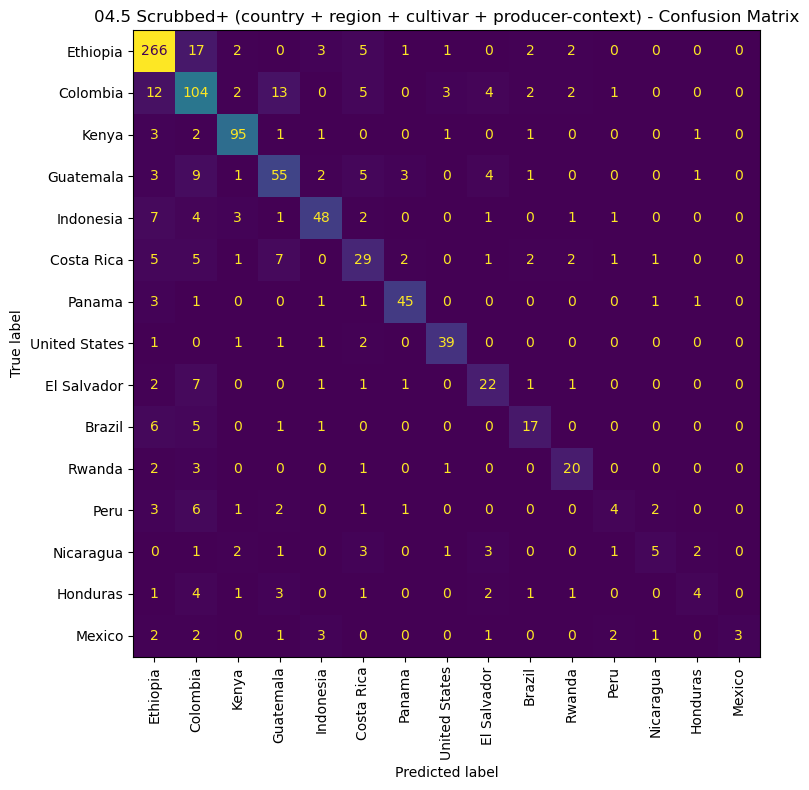

In [10]:
test_pred_output = trainer_trained.predict(test_dataset)
test_pred_ids = np.argmax(test_pred_output.predictions, axis=1)
test_true_labels = [id2label[i] for i in test_labels]
test_pred_labels = [id2label[i] for i in test_pred_ids]

print('== Test headline ==')
print(f"Macro-F1:          {f1_score(test_true_labels, test_pred_labels, average='macro', zero_division=0):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_true_labels, test_pred_labels):.4f}")
print(f"Accuracy:          {accuracy_score(test_true_labels, test_pred_labels):.4f}")

class_order = work['origin_country'].value_counts().index.tolist()
print()
print('Test per-class report:')
print(classification_report(test_true_labels, test_pred_labels, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(test_true_labels, test_pred_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('04.5 Scrubbed+ (country + region + cultivar + producer-context) - Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [11]:
with open(os.path.join(OUTPUT_DIR_ROOT, 'results.json'), 'w') as f:
    json.dump({
        'notebook': '04.5_Origin_Classification_ModernBERT_FullText_ScrubbedPlus',
        'model': MODEL_CHECKPOINT,
        'text_columns_used': EXTRA_TEXT_COLS,
        'scrub_tiers': [
            'countries_and_adjectivals',
            'coffee_region_aliases',
            'cultivars',
            'producer_context_terms',
        ],
        'num_scrub_terms': len(all_scrub_terms),
        'post_scrub_leakage_rate': leak_rate,
        'config': {
            'lr': BEST_LR, 'weighted': USE_CLASS_WEIGHTS,
            'epochs': NUM_TRAIN_EPOCHS, 'early_stop_patience': EARLY_STOP_PATIENCE,
            'seed': RANDOM_STATE, 'max_length': MAX_LENGTH,
        },
        'headline': headline,
        'baselines': {
            '04_2_blind_assessment_only': 0.1823,
            '04_3_unscrubbed_full_concat': 0.8881,
            '04_4_scrubbed_country_region_only': 0.6691,
        },
    }, f, indent=2)
print('Saved', os.path.join(OUTPUT_DIR_ROOT, 'results.json'))


Saved artifacts/origin_finetuning_modernbert_fulltext_scrubbed_plus\results.json


## Interpretation

Four-point ablation now available. Compare test Macro-F1:

| Tier | Scrubbed | Test F1 | Interpretation |
|---|---|---|---|
| 04.2 | (Blind Assessment only) | 0.182 | Clean flavor-to-origin baseline |
| 04.3 | Nothing | 0.888 | Leakage ceiling |
| 04.4 | Country + region | 0.669 | Removed explicit origin naming |
| **04.5** | + cultivars + producer context | **?** | Removed cultivar and Spanish-word shortcuts too |

### What each gap tells you

- **04.3 -> 04.4 drop (0.888 -> 0.669)**: how much came from explicit country mentions. Real leakage.
- **04.4 -> 04.5 drop**: how much came from cultivar/producer vocabulary (indirect origin signal).
  This is knowledge a trained cupper would also use -> not leakage, but important to separate.
- **04.5 vs 04.2 remaining gap**: genuine added signal from non-flavor review content
  (processing notes, adjectives, general contextual phrasing) after all known origin shortcuts removed.

### Thesis-writeup framing

> "Decomposing the gain from full review text into three tiers reveals that [X%] is explicit country
> naming (bias), [Y%] is cultivar/producer-context knowledge (legitimate but shortcut-like), and
> [Z%] is residual non-sensory textual signal (adjectives, processing notes, elevation mentions)."

Substituting the actual numbers after this notebook runs gives a clean decomposition paragraph.
